## What is a classification problem? 

A classification problem involves predicting whether something is one thing or another. 

For example, you might want to:
| Problem type | What is it? | Example |
| ---- | ---- | ---- |
| **Binary Classification** | Target can be one of two options, e.g. yes or no| Predict whether ot not someone has heart disease based on their health parameters. |
| Multi-class classification | Target can be one of more than two options | Decide whether a photo of is of food, a person or a dog. |
| Multi-label classification | Taregt can be assigned more than one opetion | predict what categories should be assigned to a wikipwdia article (e.g. mathematics, science & philosophy). |

![](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/02-different-classification-problems.png)


## What we're going to cover

In this notebook we're going to reiterate over the PyTorch workflow. 

Except instead of trying to predict a straight line (predicting a number, also called a regression problem), we'll be working on a **classification problem.**

Specifically, we're going to cover:
| Topic | Contents |
| ---- | ---- |
| **0. Architecture of a classification neural network** | Neural networks can come in almost any shape or size, but they typically follo a similar floor  plan. |
| **1. Getting binary classification data ready** | Data can be almost anything but to get started we're goint to create a simple binary classification dataset |
| **2. Building a PyTorch classification model** | Here we'll create a model to learn patterns in the data, we'll also choose a **loss function, optimizer** and build a **training loop** specific to classification. |
| **3. Fitting the model to data (training)** | We've got data and a model, now let's let the model (try to) find patterns in the (**training**) data. |
| **4. Making predictions and evaluating a model (inference)** | Our model's found patterns in the data, let's compare its findings to the actual (**testing**) data. |
| **5. Improving a model (from a model perspective)** | We've trained an evaluated a model but it's not working, let's try a few things to improve it. |
| **6. Non-linearity** | So far our model has only had the ability to model straight lines, what about non-linear (non-straight) lines? |
| **7. Replicating non-linear functions** | We used **non-linear functions** to help model non-linear data, but what do these look like? |
| **8. Putting it all together with multi-class classification** | Let's put everything we've done so far for binary classification together with a multi-class classification problem. |

# 0. Architecture of a classification neural network 

Before we get into writing code, let's look at the general architecture of a classification neural network. 

| Hyperparameter | Binary classification | Multiclass classification |
| ---- | ---- | ---- |
| **Input layer shape** (`in_features`) | Same as number of features (e.g. 5 foe age, sex, height, weight, smoking status in heart disease prediction) | Same as binary classification |
| **Hidden Layer(s)** | Problem specific, minimum = 1, maximum = unlimited | Same as binary classifcation | 
| **Neurons per hidden layer** | Problem specific, generally 10 to 512 | Same as binary classification | 
| **Output layer shape**(`out_features`) | 1(one class or the other) | 1 per class (e.g. 3 for food, person or dog photo) | 
| **Hidden layer activation** | Usually **ReLU** (rectified linear unit) but **can be many others** | Same as binary classification |
| **output activation** | **Sigmoid**(**`torch.sigmoid`** in PyTorch) | **Softmax** (**`torch.softmax`** in PyTorch) |
| **Loss function** | **Binary crossentropy** (**`torch.nn.BCELoss`** in PyTorch) | Cross entropy (**`torch.nn.CrossEntropyLoss`** in PyTorch) |
| **Optimizer** | **SGD**(stochastic gradient descent), Adam(see **`torch.optim`** for more options) | Same as binary classification |

# 1. Make classifcation data and get it ready 

We'll use the `make_circles()` method from Scikit-Learn to generate two circles with different coloured dots.

In [1]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000 

# Create circles 
X, y = make_circles(n_samples=n_samples, 
                    noise = 0.03, # a littele bit of noise to the dots
                    random_state = 42) # Keep random state so we get the same values 

In [2]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


Let's keep following the data explorer's motto of visualize, visualize, visualize and put them into a pandas DataFrame.



In [3]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0



It looks like each pair of X features (X1 and X2) has a label (y) value of either 0 or 1.

This tells us that our problem is **binary classification** since there's only two options (0 or 1).

How many values of each class is there?

In [4]:
# Check different labels
circles.label.value_counts()

1    500
0    500
Name: label, dtype: int64

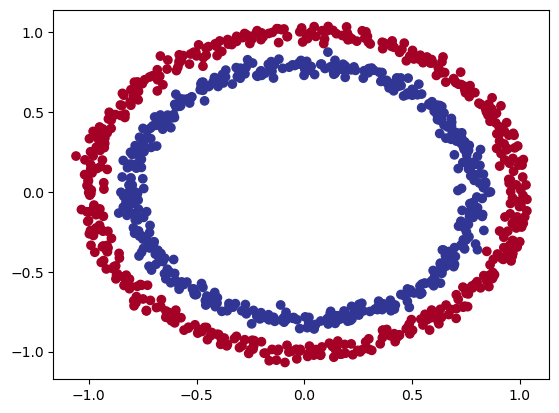

In [5]:
# Visualize with a plot 
import matplotlib.pyplot as plt 
plt.scatter(x = X[:, 0], 
            y = X[:, 1],
            c = y,
            cmap = plt.cm.RdYlBu)

## 1.1 Input and output shapes

One of the most common errors in deep learning is shape errors.

Mismatching the shapes of tensors and tensor operations with result in errors in your models.

We're going to see plenty of these throughout the course.

And there's no surefire way to making sure they won't happen, they will.

What you can do instead is continaully familiarize yourself with the shape of the data you're working with.

I like referring to it as input and output shapes.

Ask yourself:

"What shapes are my inputs and what shapes are my outputs?"

In [6]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))


Looks like we've got a match on the first dimension of each.

There's 1000 X and 1000 y.

But what's the second dimension on X?

It often helps to view the values and shapes of a single sample (features and labels).

Doing so will help you understand what input and output shapes you'd be expecting from your model.

In [7]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


This tells us the second dimension for X means it has two features (vector) where as y has a single feature (scalar).

We have two inputs for one output.

## 1.2 Turn Data into tensors and create train and test splits

We've investigated the input and output shapes of our data, now let's prepare it for being used with PyTorch and for modelling.

Specifically, we'll need to:

1. Turn our data into tensors (right now our data is in NumPy arrays and PyTorch prefers to work with PyTorch tensors).

2. Split our data into training and test sets (we'll train a model on the training set to learn the patterns between X and y and then evaluate those learned patterns on the test dataset).

In [8]:
# Turn data into tensors
# Otherwise this causes issues with computations later on 

import torch 
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

Now our data is in tensor format, let's split it into training and test sets.

To do so, let's use the helpful function `train_test_split()` from Scikit-Learn.

We'll use `test_size=0.2` (80% training, 20% testing) and because the split happens randomly across the data, let's use `random_state=42` so the split is reproducible.

In [9]:
# split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size = 0.2,    # 20% test, 80% train
                                                    random_state = 42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

# 2. Building a model

We've got some data ready, now it's time to build a model.

we'll break it down into a few parts. 

1. Setting up device agnostic code (so our model can run on CPU or GPU if it's available).

2. Constructing a model by subclassing `nn.Module`.

3. Defining a loss function and optimizer.

4. Creating a training loop (this'll be in the next section).

In [10]:
from torch import nn

device = torch.device("mps")
device

device(type='mps')

Excellent, now `device` is setup, we can use it for any data or models we create and PyTorch will handle it on the CPU (default) or GPU if it's available.


Excellent, now device is setup, we can use it for any data or models we create and PyTorch will handle it on the CPU (default) or GPU if it's available.

#### How about we create a model?

We'll want a model capable of handling our `X` data as inputs and producing something in the shape of our `y` data as ouputs.

In other words, given `X` (features) we want our model to predict `y` (label).

This setup where you have features and labels is referred to as **supervised learning**. Because your data is telling your model what the outputs should be given a certain input.

To create such a model it'll need to handle the input and output shapes of `X` and `y`.

Remember how I said input and output shapes are important? Here we'll see why.

Let's create a model class that:

1. Subclasses `nn.Module` (almost all PyTorch models are subclasses of `nn.Module`).

2. Creates 2 `nn.Linear` layers in the constructor capable of handling the input and output shapes of `X` and `y`.

3. Defines a `forward()` method containing the forward pass computation of the model.

4. Instantiates the model class and sends it to the target `device`.

In [11]:
# 1. Construct a model class that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # Takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # Takes in 5 features, produces 1 feature (y)

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature , the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)


What's going on here?

We've seen a few of these steps before.

The only major change is what's happening between `self.layer_1` and `self.layer_2`.

`self.layer_1` takes 2 input features `in_features=2` and produces 5 output features `out_features=5`.

This is known as having 5 **hidden units** or **neurons**.

This layer turns the input data from having 2 features to 5 features.

Why do this?

This allows the model to learn patterns from 5 numbers rather than just 2 numbers, potentially leading to better outputs.

I say potentially because sometimes it doesn't work.

The number of hidden units you can use in neural network layers is a **hyperparameter** (a value you can set yourself) and there's no set in stone value you have to use.

Generally more is better but there's also such a thing as too much. The amount you choose will depend on your model type and dataset you're working with.

Since our dataset is small and simple, we'll keep it small.

The only rule with hidden units is that the next layer, in our case, `self.layer_2` has to take the same `in_features` as the previous layer `out_features`.

That's why `self.layer_2` has `in_features=5`, it takes the `out_features=5` from `self.layer_1` and performs a linear computation on them, turning them into `out_features=1` (the same shape as `y`).

A visual example of what a similar classificiation neural network to the one we've just built looks like. Try create one of your own on the [TensorFlow Playground website](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.74643&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false).

You can also do the same as above using **`nn.Sequential`**.

**`nn.Sequential`** performs a forward pass computation of the input data through the layers in the order they appear.

In [12]:
# Replicate CircleModelV0 with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [13]:
# Make predictions with the model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.0583],
        [-0.0042],
        [ 0.0152],
        [-0.0800],
        [ 0.3571],
        [ 0.3874],
        [ 0.2688],
        [ 0.3614],
        [ 0.0007],
        [ 0.0032]], device='mps:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


## 2.2 Stepup loss function and optimizer

| Loss function/Optimizer | Problem type | PyTorch Code |
| ---- | ---- | ---- |
| Stochastic Gradient Descent (SGD) optimizer | Classification, regression, many others. | [torch.optim.SGD()](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) |
| Adam Optimizer | Classification, regression, many others. | [torch.optim.Adam()](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) | 
| Binary cross entropy loss | Binary classification | [torch.nn.BCEWithLogitsLoss](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) or [torch.nn.BCELoss](https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html) |
| Cross entropy loss | Multi-class classification | [torch.nn.CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) |
| Mean absolute error (MAE) or L1 Loss | Regression | [torch.nn.L1Loss](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html) |
| Mean squared error (MSE) or L2 Loss | Regression | [torch.nn.MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#torch.nn.MSELoss) |

PyTorch has two binary cross entropy implementations:

1. torch.nn.BCELoss() - Creates a loss function that measures the binary cross entropy between the target (label) and input (features).

2. torch.nn.BCEWithLogitsLoss() - This is the same as above except it has a sigmoid layer (nn.Sigmoid) built-in (we'll see what this means soon).

### Which one should you use?

The documentation for torch.nn.BCEWithLogitsLoss() states that it's more numerically stable than using `torch.nn.BCELoss()` after a `nn.Sigmoid` layer.

So generally, implementation 2 is a better option. However for advanced usage, you may want to separate the combination of `nn.Sigmoid` and `torch.nn.BCELoss()` but that is beyond the scope of this notebook.

In [14]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitLoss = sigmoid built -in

# Create an optimizer 
optimizer = torch.optim.SGD(params=model_0.parameters(), 
                            lr = 0.1)


Now let's also create an **evaluation metric**.

An evaluation metric can be used to offer another perspective on how your model is going.

If a loss function measures how wrong your model is, I like to think of evaluation metrics as measuring how right it is.

Of course, you could argue both of these are doing the same thing but evaluation metrics offer a different perspective.

After all, when evaluating your models it's good to look at things from multiple points of view.

There are several evaluation metrics that can be used for classification problems but let's start out with **accuracy**.

Accuracy can be measured by dividing the total number of correct predictions over the total number of predictions.

For example, a model that makes 99 correct predictions out of 100 will have an accuracy of 99%.

In [15]:
# Claculate accuarcy (a classification metrics)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc 

# 3. Train model

Okay, now we've got a loss function and optimizer ready to go, let's train a model.


## 3.1 Going from raw model outputs to predicted labels (logits -> prediction probabilities -> prediction labels)
 
Before we the training loop steps, let's see what comes out of our model during the forward pass (the forward pass is defined by the `forward()` method). 

To do so, let's pass the model some data. 

In [16]:
# View the first 5 outputs of the forward pass on the test data
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0583],
        [-0.0042],
        [ 0.0152],
        [-0.0800],
        [ 0.3571]], device='mps:0', grad_fn=<SliceBackward0>)

In [17]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4854],
        [0.4989],
        [0.5038],
        [0.4800],
        [0.5883]], device='mps:0', grad_fn=<SigmoidBackward0>)


Okay, it seems like the outputs now have some kind of consistency (even though they're still random).

They're now in the form of **prediction probabilities**, in other words, the values are now how much the model thinks the data point belongs to one class or another.

In our case, since we're dealing with binary classification, our ideal outputs are 0 or 1.

So these values can be viewed as a decision boundary.

The closer to 0, the more the model thinks the sample belongs to class 0, the closer to 1, the more the model thinks the sample belongs to class 1.

More specificially:

* If `y_pred_probs` >= 0.5, `y=1` (class 1)

* If `y_pred_probs` < 0.5, `y=0` (class 0)

To turn our prediction probabilities in prediction labels, we can round the outputs of the sigmoid activation function.

In [18]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# in full 
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality 
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension 
y_preds.squeeze()

tensor([True, True, True, True, True], device='mps:0')


tensor([0., 0., 1., 0., 1.], device='mps:0', grad_fn=<SqueezeBackward0>)

## 3.2 Building a trsining and testing loop 

Alright, we've discussed how to take our raw model outputs and convert them to prediction labels, now let's build a training loop.

Let's start by training for 100 epochs and outputing the model's progress every 10 epochs.

In [19]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target and target device 
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evalution loop 
for epoch in range(epochs):

    ## Training 
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train).squeeze()       # squeeze to remove extra `1` dimensions, this won't work unless model and data are on same device 
    y_pred = torch.round(torch.sigmoid(y_logits))       # turn logits -> pred probs -> pred labls
  
    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # Using nn.BCELoss you need torch.sigmoid()
    #                y_train)
    loss = loss_fn(y_logits,    # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train)
    acc = accuracy_fn(y_true = y_train,
                      y_pred = y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4.Loss backwards
    loss.backward()

    # 5. Optimizer step 
    optimizer.step()

    ## Testing 
    model_0.eval()
    with torch.inference_mode():

        # 1. Forward pass 
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate loss/accuracy 
        test_loss = loss_fn(test_logits,    
                            y_test)
        
        test_acc = accuracy_fn(y_true=y_test, 
                               y_pred=test_pred)
    
    # Print out what's happening every 10 epochs
    if epoch % 10 == 0 :
        print(f"Epoch: {epoch} | Training Loss: {loss:.5f}, Training Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Training Loss: 0.70044, Training Accuracy: 51.75% | Test loss: 0.69833, Test Accuracy: 55.50%
Epoch: 10 | Training Loss: 0.69752, Training Accuracy: 50.50% | Test loss: 0.69613, Test Accuracy: 55.00%
Epoch: 20 | Training Loss: 0.69617, Training Accuracy: 49.38% | Test loss: 0.69514, Test Accuracy: 53.50%
Epoch: 30 | Training Loss: 0.69542, Training Accuracy: 50.12% | Test loss: 0.69458, Test Accuracy: 51.00%
Epoch: 40 | Training Loss: 0.69493, Training Accuracy: 50.38% | Test loss: 0.69420, Test Accuracy: 50.00%
Epoch: 50 | Training Loss: 0.69457, Training Accuracy: 50.38% | Test loss: 0.69391, Test Accuracy: 47.00%
Epoch: 60 | Training Loss: 0.69430, Training Accuracy: 50.75% | Test loss: 0.69369, Test Accuracy: 45.50%
Epoch: 70 | Training Loss: 0.69409, Training Accuracy: 50.62% | Test loss: 0.69351, Test Accuracy: 45.50%
Epoch: 80 | Training Loss: 0.69392, Training Accuracy: 50.62% | Test loss: 0.69337, Test Accuracy: 47.00%
Epoch: 90 | Training Loss: 0.69379, Training Ac

It looks like it went through the training and testing steps fine but the results don't seem to have moved too much. 

The accuracy barely moves above 50% on each data split.

And because we're working with a balanced binary classificatiton problem, it means our model is performing as good as random guesing (with 500 samples of class 0 and class 1 a model predicting class 1 every single time would achieve 50% accuracy)

# 4. Make predictions and evalute the model

From the metrics it looks like our model is random guessing.

How could we investigate this further?

I've got an idea.

The data explorer's motto!

"Visualize, visualize, visualize!"

Let's make a plot of our model's predictions, the data it's trying to predict on and the decision boundary it's creating for whether something is class 0 or class 1.

In [20]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


/Users/dhavalantala/Desktop/pytorch/venv/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: dlopen(/Users/dhavalantala/Desktop/pytorch/venv/lib/python3.9/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIxEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  Referenced from: <CAE66874-17C2-35C9-9C4D-6BA9770AF17F> /Users/dhavalantala/Desktop/pytorch/venv/lib/python3.9/site-packages/torchvision/image.so
  Expected in:     <DAEF2BE1-BBB4-3005-8003-63A504CDB9D9> /Users/dhavalantala/Desktop/pytorch/venv/lib/python3.9/site-packages/torch/lib/libtorch_cpu.dylib
  warn(f"Failed to load image Python extension: {e}")


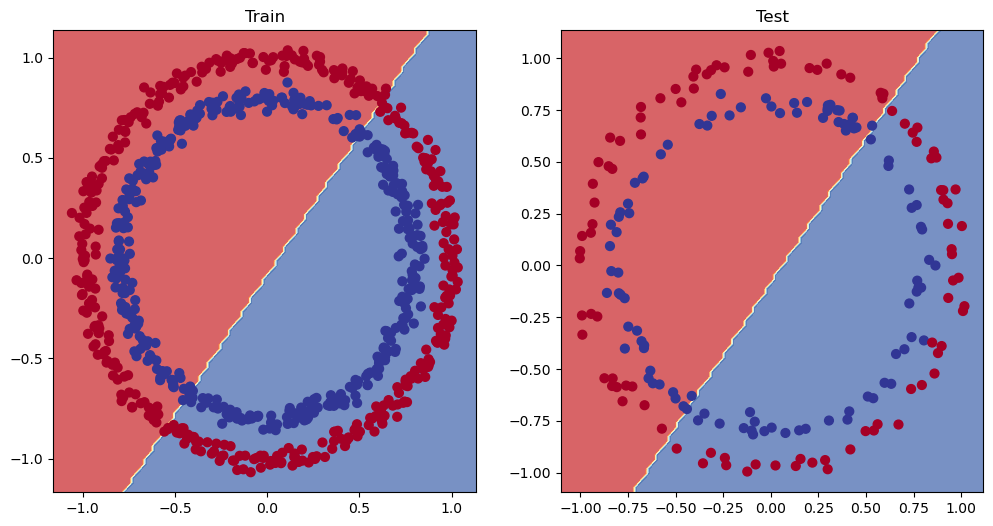

In [21]:
# plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

It seems like we've found the cause of model's performance issue.

It's currently trying to split the red and blue dots using a straight line...

That explains the 50% accuracy. Since our data is circular, drawing a straight line can at best cut it down the middle.

In machine learning terms, our model is **underfitting**, meaning it's not learning predictive patterns from the data.

# 5. Improving a model(from a model perspective)

Let's try to fix our model's underfitting problem. 

Focusing specifically on the model (not the data), there are a few ways we could do this. 

| Model improvement technique* | What does it do? |
| ---- | ---- |
| **Add more layers** | Each layer potentially increases the learning capabilities of the model with each layer being able to learn some kind of new pattern in the data, more layers is often referred to as making your neural network deeper. | 
| **Add more hidden units** | Similar to the above, more hidden units per layer means a potential increase in learning capabilities of the model, more hidden units is often referred to as making your neural network wider. |
| **Fitting for longer (more epochs)** | Your model might learn if it had more opportunities to look at the data. |
| **Changing the activation functions** | Some data just can'be fit with only straight lines (like what we've seen), using non-linear activation functions can help with this(hint, hint). |
| **Change the learning rate** | Less model specific, but still related, the learning rate of the optimizer decides how much a model should change its parameters each step, too much and the model overcorrects, too little and it doesn't learn enough. | 
| **Change the loss function** | Again, less model specific but still important, different problems require different loss functions. For example, a binary cross entropy loss function won't work with a multi-class classification problem. |
| **Use transfer learning** | take a pretained model from a problem domain similar to your and adjust it to your own problem. |

Let's see what happens if we add an extra layer to our model, fit for longer (`epochs=1000` instead of `epochs=100`) and increase the number of hidden units from 5 to 10.

We'll follow the same steps we did above but with a few changed hyperparameters.

In [22]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)   # extra layer
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [23]:
# loss_fn = nn.BCELoss() # Requires sigmoid on input
loss_fn = nn.BCEWithLogitsLoss() # Does not require sigmoid on input
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

In [24]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

epochs = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

    ## Training 
    # 1. Forward Pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))   # logits -> predicition probabilities -> prediction labels

    # 2. Calculate loss/accuracy 
    loss = loss_fn(y_logits, y_train)
    training_acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4.Loss backwards 
    loss.backward()

    # 5.Optimizer step
    optimizer.step()

    ## Testing
    model_1.eval()

    with torch.inference_mode():

        # 1.Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2.Calculate loss/accuracy
        test_loss = loss_fn(test_logits, 
                            y_test)

        test_acc = accuracy_fn(y_true=y_test, 
                               y_pred=test_pred)
    
    # Print out what's happening every 10 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f}, Train Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 0.69396, Train Accuracy: 50.38% | Test loss: 0.69261, Test Accuracy: 51.00%
Epoch: 100 | Train Loss: 0.69305, Train Accuracy: 50.38% | Test loss: 0.69379, Test Accuracy: 48.00%
Epoch: 200 | Train Loss: 0.69299, Train Accuracy: 50.38% | Test loss: 0.69437, Test Accuracy: 46.00%
Epoch: 300 | Train Loss: 0.69298, Train Accuracy: 50.38% | Test loss: 0.69458, Test Accuracy: 45.00%
Epoch: 400 | Train Loss: 0.69298, Train Accuracy: 50.38% | Test loss: 0.69465, Test Accuracy: 46.00%
Epoch: 500 | Train Loss: 0.69298, Train Accuracy: 50.38% | Test loss: 0.69467, Test Accuracy: 46.00%
Epoch: 600 | Train Loss: 0.69298, Train Accuracy: 50.38% | Test loss: 0.69468, Test Accuracy: 46.00%
Epoch: 700 | Train Loss: 0.69298, Train Accuracy: 50.38% | Test loss: 0.69468, Test Accuracy: 46.00%
Epoch: 800 | Train Loss: 0.69298, Train Accuracy: 50.38% | Test loss: 0.69468, Test Accuracy: 46.00%
Epoch: 900 | Train Loss: 0.69298, Train Accuracy: 50.38% | Test loss: 0.69468, Test Accuracy:

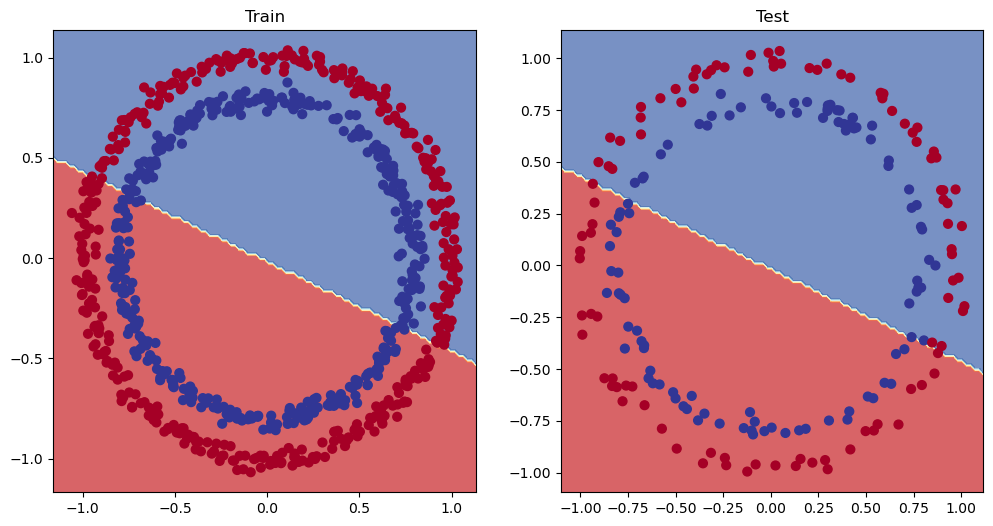

In [25]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

## 5.1 Preparing data to see if our model can model a straight line



In [26]:
# Create some data (same as notebook 01)

weight = 0.7
bias = 0.3
start = 0 
end = 1
step = 0.01

# Create data 
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias     # linear regression formula

# check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [27]:
# Create train and test splits
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each
len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)


(80, 20, 80, 20)

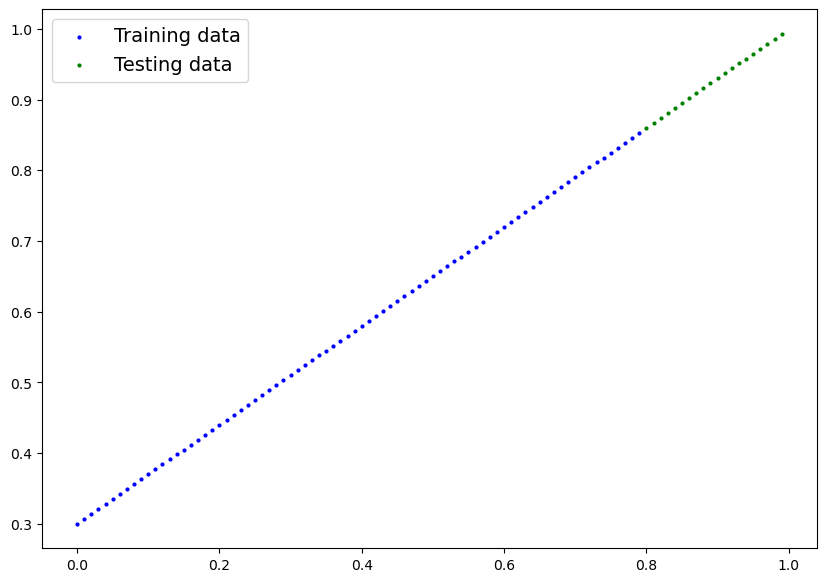

In [28]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

## 5.2 Adjusting `model_1` to fit a straight line 

Now we've got some data, let's recreate `model_1` but with a loss function suited to our regression data. 

In [29]:
# Some architecture as model_1 (but using nn.Sequential)

model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)


We'll setup the loss function to be `nn.L1Loss()` (the same as mean absolute error) and the optimizer to be `torch.optim.SGD()`.

In [30]:
# Loss and optimizer
loss_fn = nn.L1Loss() # MAE loss with regression data
optimizer = torch.optim.SGD(params=model_2.parameters(), 
                            lr=0.01)

In [31]:
# Train the model
torch.manual_seed(42)
torch.mps.manual_seed(42)

# set the number of epochs
epochs = 1000

# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    y_pred = model_2(X_train_regression)
    loss = loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    ## Testing
    model_2.eval()

    with torch.inference_mode():

        # 1.Forward pass 
        test_pred = model_2(X_test_regression)
        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test_regression)

    # print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

/Users/dhavalantala/Desktop/pytorch/venv/lib/python3.9/site-packages/torch/autograd/__init__.py:200: UserWarning: The operator 'aten::sgn.out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1682343673238/work/aten/src/ATen/mps/MPSFallback.mm:11.)
  Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch: 0 | Train Loss: 0.75986 | Test Loss: 0.91103
Epoch: 100 | Train Loss: 0.02858 | Test Loss: 0.00081
Epoch: 200 | Train Loss: 0.02533 | Test Loss: 0.00209
Epoch: 300 | Train Loss: 0.02137 | Test Loss: 0.00305
Epoch: 400 | Train Loss: 0.01964 | Test Loss: 0.00341
Epoch: 500 | Train Loss: 0.01940 | Test Loss: 0.00387
Epoch: 600 | Train Loss: 0.01903 | Test Loss: 0.00379
Epoch: 700 | Train Loss: 0.01878 | Test Loss: 0.00381
Epoch: 800 | Train Loss: 0.01840 | Test Loss: 0.00329
Epoch: 900 | Train Loss: 0.01798 | Test Loss: 0.00360


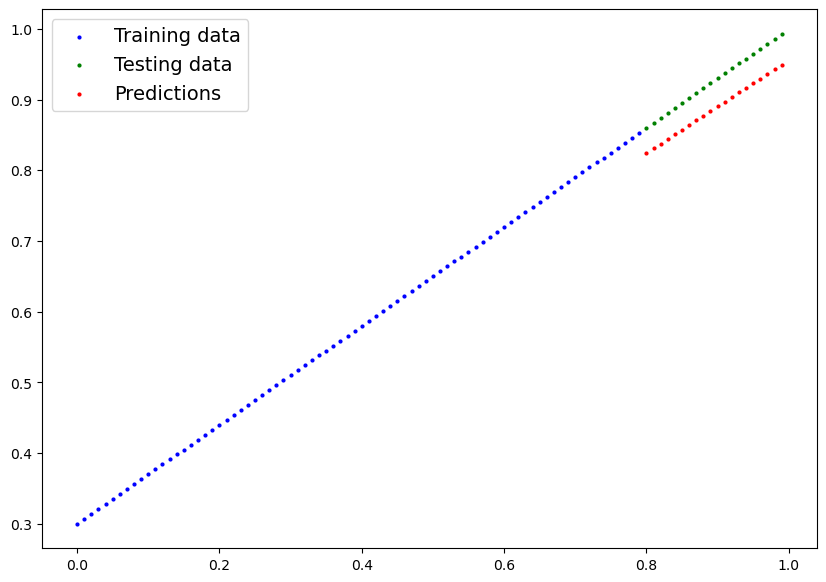

In [32]:
# Turn on evaluation mode
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
  y_preds = model_2(X_test_regression)

# Plot data and predictions
plot_predictions(train_data=X_train_regression.cpu(), 
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu()); 

Alright, it looks like our model is able to do far better than random guessing on straight lines.

This is a good thing.

It means our model at least has some capacity to learn.

# 6. The missing piece: non-linearity

we've seen our model can draw stright lines, thanks to its linear layers. 

But how about we give it the capacity to draw non-stright (non-linear) lines?

## 6. Recreating non-linear data

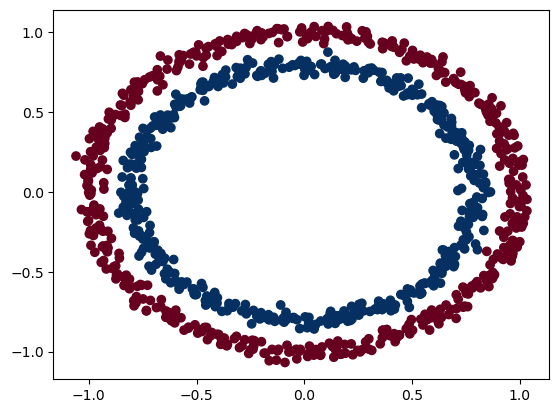

In [33]:
# make and plot data 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=1000, 
                    noise = 0.03,
                    random_state = 42,
)

plt.scatter(X[:, 0], 
            X[:, 1], 
            c=y, 
            cmap=plt.cm.RdBu)

Nice! now let's split it into training and test sets using 80% of the data for training and 20% for testing. 

In [34]:
# Convert to tensors and split into train and test sets
import torch 
from sklearn.model_selection import train_test_split

# turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = 0.2,
                                                    random_state = 42
)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

## 6.2 Building a model with non-linearity

Now here comes the fun part. 

What kind of pattern do you think you could draw with unlimited straight (linear) and non-straight (non-linear) lines?

I bet you could get pretty creative.

So far our neural networks have only been using linear (straight) line functions.

But the data we've been working with is non-linear (circles).

What do you think will happen when we introduce the capability for our model to use **`non-linear actviation functions`**?

In [35]:
# Building model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=20)
        self.layer_2 = nn.Linear(in_features=20, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()  # <- add in ReLU activation function

        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Intersperse the ReLU activation function between layers
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=20, bias=True)
  (layer_2): Linear(in_features=20, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [36]:
# setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model_3.parameters(), 
                            lr = 0.1)

## 6.3 Training a model with non-linearity
You know the drill, model, loss function, optimizer ready to go, let's create a training and testing loop. 

In [37]:
# Fit model 
torch.manual_seed(42)
torch.mps.manual_seed(42)

epochs = 1000 

# Put all data on target device 
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

    # 1. Forward Pass 
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))   # logits -> prediction probabilities -> prediction labels

    # 2. Caculate loss and accuracy 
    loss = loss_fn(y_logits, y_train)  #BCEWithLogitsLoss calculate loss using logits
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred)

    # 3. Optimizer sero grad 
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Testing 
    model_3.eval()
    with torch.inference_mode():

        # 1. Forward pass 
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))     # logits -> prediction probabilities -> prediction labels

        # 2. Calculate loss and accuracy 
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69478, Accuracy: 43.88% | Test Loss: 0.69517, Test Accuracy: 47.50%
Epoch: 100 | Loss: 0.69125, Accuracy: 58.25% | Test Loss: 0.69197, Test Accuracy: 53.50%
Epoch: 200 | Loss: 0.68889, Accuracy: 53.62% | Test Loss: 0.68924, Test Accuracy: 54.00%
Epoch: 300 | Loss: 0.68550, Accuracy: 60.88% | Test Loss: 0.68548, Test Accuracy: 64.50%
Epoch: 400 | Loss: 0.67918, Accuracy: 67.00% | Test Loss: 0.67917, Test Accuracy: 69.00%
Epoch: 500 | Loss: 0.66758, Accuracy: 68.75% | Test Loss: 0.66830, Test Accuracy: 73.50%
Epoch: 600 | Loss: 0.64409, Accuracy: 80.00% | Test Loss: 0.64764, Test Accuracy: 79.50%
Epoch: 700 | Loss: 0.59269, Accuracy: 92.62% | Test Loss: 0.60398, Test Accuracy: 91.50%
Epoch: 800 | Loss: 0.48951, Accuracy: 97.75% | Test Loss: 0.51283, Test Accuracy: 97.00%
Epoch: 900 | Loss: 0.33257, Accuracy: 99.25% | Test Loss: 0.36625, Test Accuracy: 99.00%


## 6.4 Evaluating a model trained woth non-linear activation functions

Remember how our circle data is non-linear? Well, let's see how our models predictions look now the model's been trained with non-linear activation functions.

In [38]:
# Make predictions
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='mps:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='mps:0'))

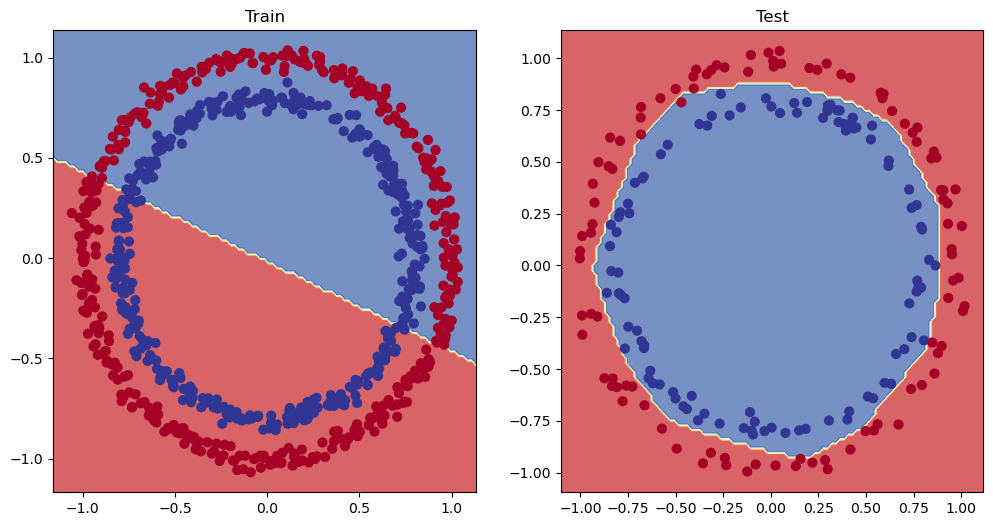

In [39]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity

# 7 Replicating non-linear activation functions

we saw before how adding non-linear activation functions to our model can help it to model non-linear data.


In [40]:
# Create a toy tensor (similar to the data going into our models)
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

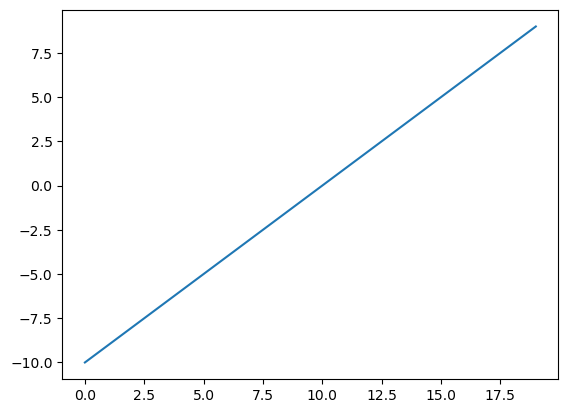

In [41]:
# Visualize the toy tensor
plt.plot(A);

In [42]:
# Create ReLU functions by hand
def relu(x):
    return torch.maximum(torch.tensor(0), x) # inputs must be tensor 

# pass toy tensor through ReLU function
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

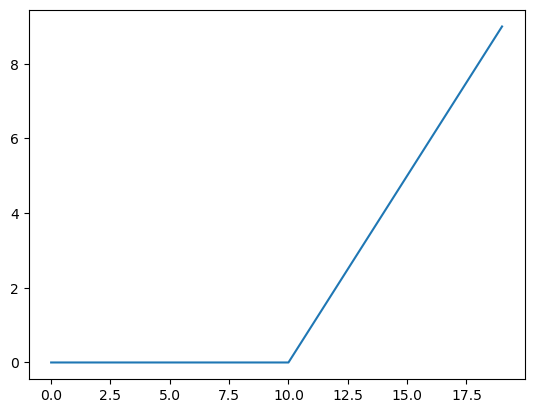

In [43]:
plt.plot(relu(A))

In [44]:
# Create a custom sigmoid function
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

# Test custom sigmoid on toy tensor 
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

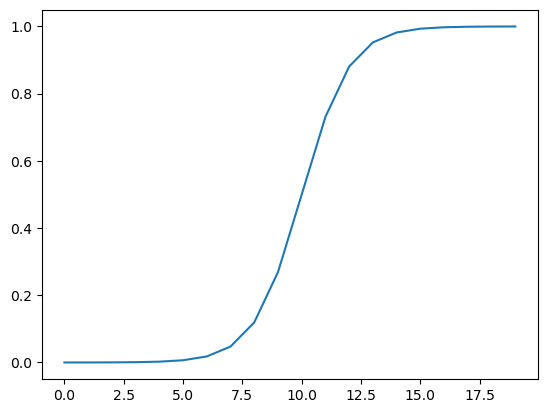

In [45]:
# Plot sigmoid acivated toy tensor 
plt.plot(sigmoid(A))

# 8 Putting things together by building a multi-class PyTorch model

We've coverd a fair bit.

But now let's put it all together using a multi-class classification problem.

Recall a **binary classification** problem deals with classifying somethings as one of two options (e.g. a photo as a cat phto or a dog photo) where as a **multi-class classication problem deals with classifying something from a list more than two options(e.g. classifying a photo as a cat a dog or a chicken).

![](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/02-binary-vs-multi-class-classification.png)

## 8.1 Creating multi-class classification data

To begin a multi-class classification problem, let's create some multi-c;ass data.

To do so, we can leverage Scikit-Learn's `make_blobs()` method.

This method will create however many classes (using the `centers` parameter) we want.

Specifically, let's do the following:

1. Create some multi-class data with `make_blobs()`.
2. Turn the data into tensors (the default of make_blobs() is to use NumPy arrays).
3. Split the data into training and test sets using train_test_split().
4. Visualize the data.

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


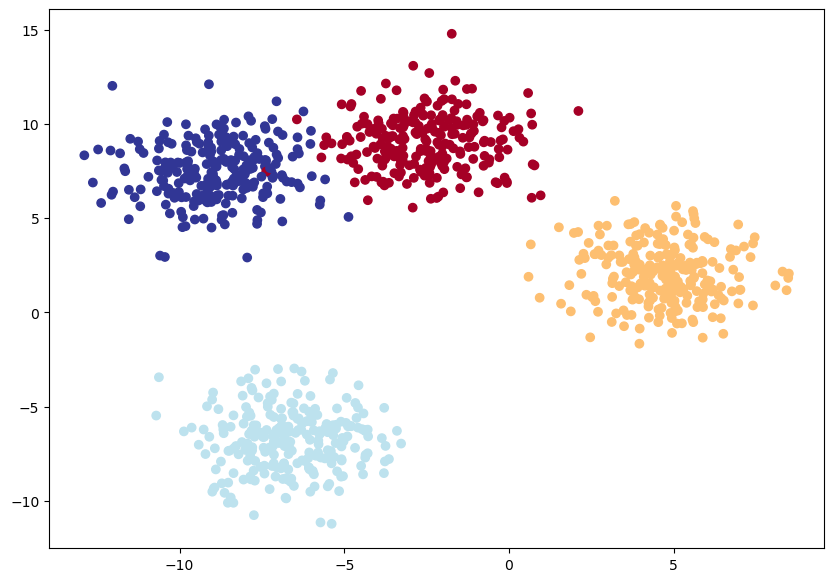

In [46]:
# Import dependencies 
import torch
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4 
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. create multi-class data 
X_blob, y_blob = make_blobs(
                            n_samples = 1000,
                            n_features = NUM_FEATURES,  # features
                            centers = NUM_CLASSES,   # y labels
                            cluster_std = 1.5,   # give the cluster a little shake up (try changing this to 1.0 ,the defults)
                            random_state = RANDOM_SEED 
)

# 2. Turn data into tensor 
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
                                                                        X_blob,
                                                                        y_blob,
                                                                        test_size = 0.2,
                                                                        random_state = RANDOM_SEED
)

# 4. Plot data 
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap = plt.cm.RdYlBu);

In [47]:
device = torch.device("mps")

## 8.2 Building a multi-class classification model in PyTorch

We've created a few models in PyTorch so far.

You might also be starting to get an idea of how flexible neural networks are.

You might also be build one similar to `model_3` but this still capable to handling multi-class data?

To do so, let's create a subclass of `nn.Module` that takes in three hyperparameters:

* `input_features` - the number of `X` features coming into the model.
* `output_features` - the ideal numbers of output features we'd like (this will be equivalent to `NUM_CLASSES` or the number of classes in your multi-class classification problem).
* `hidden_units` - the number of hidden neurons we'd like each hidden layer to use.


In [48]:
from torch import nn

# Build model 
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features of the model
              (how many classes there are).
            hidden_units (int): Number of hidden units between layers, default 8.
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features = input_features, out_features=hidden_units),
            nn.ReLU(),  # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features = hidden_units, out_features = hidden_units),
            nn.ReLU(),  # <- does our dataset require non-linear layers? (try uncommenting and see if the results change)
            nn.Linear(in_features = hidden_units, out_features = output_features)   # how many classes are there?
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(
                    input_features = NUM_FEATURES,
                    output_features = NUM_CLASSES,
).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

## 8.3 Creating a loss function and optimizer for a multi-class PyTorch model

Since we're working on a multi-class classification problem, we'll use the nn.`CrossEntropyLoss()` method as our loss function.

And we'll stick with using SGD with a learning rate of 0.1 for optimizing our ``model_4`` parameters.

In [49]:
# Create loss and optimizer 
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),
                            lr = 0.1)   # exercise: try changing the learning rate here and seeing what happens to the model's performance

## 8.4 Getting prediction probabilities for a multi-class PyTorch model

Alright, we've got a loss function and optimizer ready, and we're ready to train our model but before we do let's do a single forward pass with our model to see if it works.

In [50]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
model_4(X_blob_train.to(device))[:5]

tensor([[-0.7586, -0.6810, -1.5180, -1.1178],
        [-0.2398, -1.2335, -0.9858, -0.2899],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [ 0.2391, -0.2472,  0.1494,  0.0213],
        [-0.1214, -0.9804, -0.6918, -0.1923]], device='mps:0',
       grad_fn=<SliceBackward0>)

In [51]:
# How many elements in a single prediction sample?
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES 

(torch.Size([4]), 4)

Do you remember what the raw outputs of our model are called?

Hint: it rhymes with "frog splits" (no animals were harmed in the creation of these materials).

If you guessed logits, you'd be correct.

So right now our model is outputing logits but what if we wanted to figure out exactly which label is was giving the sample?

As in, how do we go from `logits -> prediction probabilities -> prediction labels` just like we did with the binary classification problem?

That's where the softmax activation function comes into play.

The softmax function calculates the probability of each prediction class being the actual predicted class compared to all other possible classes.

If this doesn't make sense, let's see in code.

In [52]:
# Make prediction logits with model
y_logits = model_4(X_blob_test.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities 
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]], device='mps:0',
       grad_fn=<SliceBackward0>)
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]], device='mps:0',
       grad_fn=<SliceBackward0>)


In [53]:
# Sum the first sample output of the softmax activation function
torch.sum(y_pred_probs[0])

tensor(1., device='mps:0', grad_fn=<SumBackward0>)

These prediction probablities are essentially saying how much the model thinks the target `X` sample (the input) maps to each class.

Since there's one value for each class in `y_pred_probs`, the index of the *highest* value is the class the model thinks the specific data sample most belongs to.

We can check which index has the highest value using `torch.argmax()`.

In [54]:
# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.3169, 0.3244, 0.1405, 0.2182], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor(1, device='mps:0')


We can see the output of `torch.argmax()` returns 2, so for the features (`X`) of the sample at index 0, the model is predicting that the most likely class value (`y`) is 2.

Of course, right now this is just random guessing so it's got a 25% chance of being right (since there's four classes). But we can improve those chances by training the model.

## 8.5 Creating a training and testing loop for a multi-class PyTorch model

Alright, now we've got all of the preparation steps out of the way, let's write a training and testing loop to improve and evaluate our model.

We've done many of these steps before so much of this will be practice.

The only difference is that we'll be adjusting the steps to turn the model outputs (logits) to prediction probabilities (using the softmax activation function) and then to prediction labels (by taking the argmax of the output of the softmax activation function).

Let's train the model for `epochs=100` and evaluate it every 10 epochs.

In [55]:
# Put data to target device 
# X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
# X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

In [56]:
# Fit the model
torch.manual_seed(42)
torch.mps.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to target device 
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train) # model outputs raw logits 
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # go from logits -> prediction probabilities -> prediction labels
    # print(y_logits)
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train) 
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.15883, Acc: 40.38% | Test Loss: 1.07554, Test Acc: 48.00%


Epoch: 10 | Loss: 0.64476, Acc: 96.75% | Test Loss: 0.66069, Test Acc: 97.50%
Epoch: 20 | Loss: 0.42535, Acc: 98.50% | Test Loss: 0.43074, Test Acc: 100.00%
Epoch: 30 | Loss: 0.25294, Acc: 99.12% | Test Loss: 0.24508, Test Acc: 99.50%
Epoch: 40 | Loss: 0.11232, Acc: 99.25% | Test Loss: 0.10229, Test Acc: 99.50%
Epoch: 50 | Loss: 0.06627, Acc: 99.25% | Test Loss: 0.05848, Test Acc: 99.50%
Epoch: 60 | Loss: 0.05068, Acc: 99.25% | Test Loss: 0.04293, Test Acc: 99.50%
Epoch: 70 | Loss: 0.04300, Acc: 99.25% | Test Loss: 0.03491, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03836, Acc: 99.25% | Test Loss: 0.02988, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03525, Acc: 99.25% | Test Loss: 0.02663, Test Acc: 99.50%


## 8.6 Making and evaluating predictions with a PyTorch multi-class model

It looks like our trained model is performaning pretty well.

But to make sure of this, let's make some predictions and visualize them.

In [57]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[-0.6249,  5.9860, -7.6323, -8.4470],
        [-2.1738, -6.3750, -3.7202,  3.1203],
        [-3.4102, -3.8958,  3.1567, -2.6119],
        [-1.1505,  4.1962, -3.8472, -4.8820],
        [ 3.7548, -1.3391, -9.1422, -6.9465],
        [-2.8211, -7.5767, -4.2944,  3.7944],
        [-3.0306, -3.3328,  2.7955, -2.1374],
        [ 3.3762, -4.0375, -6.8987, -3.5503],
        [-4.3620, -4.9904,  3.8123, -3.3814],
        [ 3.5012, -3.0281, -7.5401, -4.7064]], device='mps:0')

In [58]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='mps:0')
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='mps:0')
Test accuracy: 99.5%


Nice! Our model predictions are now in the same form as our test labels.

Let's visualize them with `plot_decision_boundary()`, remember because our data is on the GPU, we'll have to move it to the CPU for use with matplotlib (``plot_decision_boundary()`` does this automatically for us).

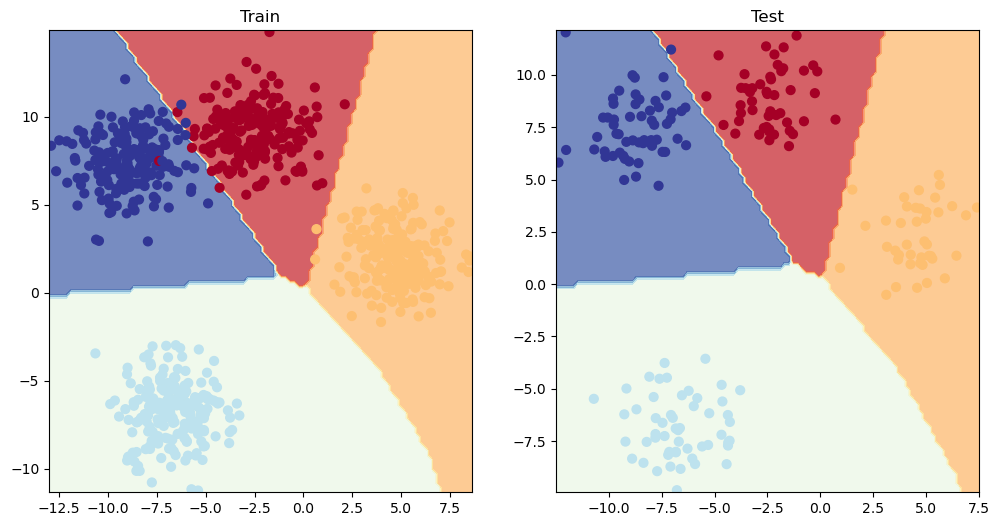

In [59]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

# 9. More classification evaluation metrics

So far we've only covered a couple of ways of evaluating a classification model (accuracy, loss and visualizing predictions).

These are some of the most common methods you'll come across and are a good starting point.

However, you may want to evaluate your classification model using more metrics such as the following:

| Metric name/Evaluation method | Defination | Code |
| ---- | ---- | --- | 
| Accuracy | Out of 100 predictions, how many does your model get correct? E.g. 95% accuracy means it gets 95/100 predictions correct. | [torchmetrics.Accuracy()](https://torchmetrics.readthedocs.io/en/stable/classification/accuracy.html#id3) or [sklearn.metrics.accuracy_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) |
| Precision | Proportion of true positives over total number of samples. Higher precision leads to less false positives (model predicts 1 when it should've been 0). | [torchmetrics.Precision()](https://torchmetrics.readthedocs.io/en/stable/classification/precision.html#id4) or [sklearn.metrics.precision_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html) |
| Recall | Proportion of true positives over total number of true positives and false negatives (model predicts 0 when it should've been 1). Higher recall leads to less false negatives. | [torchmetrics.Recall()](https://torchmetrics.readthedocs.io/en/stable/classification/recall.html#id5) or [sklearn.metrics.recall_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) |
| F1-score | Combines precision and recall into one metric. 1 is best, 0 is worst. | [torchmetrics.F1Score()](https://torchmetrics.readthedocs.io/en/stable/classification/f1_score.html#f1score) or [sklearn.metrics.f1_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) |
| Confusion matrix | Compares the predicted values with the true values in a tabular way, if 100% correct, all values in the matrix will be top left to bottom right (diagnol line). | [torchmetrics.ConfusionMatrix](https://torchmetrics.readthedocs.io/en/stable/classification/confusion_matrix.html#confusionmatrix) or [sklearn.metrics.plot_confusion_matrix()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions) |
| Classification report | Collection of some of the main classification metrics such as precision, recall and f1-score. | [sklearn.metrics.classification_report()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) |

In [60]:
try:
    from torchmetrics import Accuracy
except:
    !pip install torchmetrics==0.9.3 # this is the version we're using in this notebook (later versions exist here: https://torchmetrics.readthedocs.io/en/stable/generated/CHANGELOG.html#changelog)
    from torchmetrics import Accuracy

# Setup metric and make sure it's on the target device
torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)

# Calculate accuracy
torchmetrics_accuracy(y_preds, y_blob_test)

/Users/dhavalantala/Desktop/pytorch/venv/lib/python3.9/site-packages/torchmetrics/utilities/checks.py:49: UserWarning: MPS: no support for int64 min/max ops, casting it to int32 (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1682343673238/work/aten/src/ATen/native/mps/operations/ReduceOps.mm:1271.)
  if ignore_index is None and target.min() < 0:


tensor(0.9950, device='mps:0')

In [61]:
from torchmetrics import Accuracy

# Setup metric
torchmetric_accuracy = Accuracy().to(device)

# Calculuate accuracy
torchmetric_accuracy(y_preds, y_blob_test)

tensor(0.9950, device='mps:0')

## Exercises

In [62]:
import torch
from torch import nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 

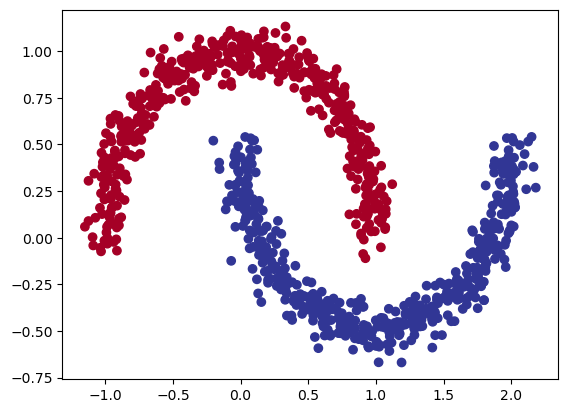

In [63]:
# Hyperparametr 
RANDOM_SEED = 42
NUM_SAMPLES = 1000

X_moons, y_moons = make_moons(n_samples=NUM_SAMPLES,
                              noise = 0.07, # Replace form 0.03 to 0.07
                              random_state = RANDOM_SEED)


X_moons = torch.from_numpy(X_moons).type(torch.float)
y_moons = torch.from_numpy(y_moons).type(torch.float)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
                                                                            X_moons,
                                                                            y_moons,
                                                                            test_size = 0.2,
                                                                            random_state = RANDOM_SEED
)

plt.scatter(X_moons[:, 0], X_moons[:,1], c=y_moons, cmap=plt.cm.RdYlBu)

In [64]:
class MoonModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # self.layer_1 = nn.Linear(in_features=2, out_features=10)
        # self.layer_2 = nn.Linear(in_features=10, out_features=10)
        # self.layer_3 = nn.Linear(in_features=10, out_features=1)
        # self.relu = nn.ReLU()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=2, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=1)
        )
    def forward(self, x):
        # return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
        return self.linear_layer_stack(x)

model_5 = MoonModelV0().to(device)
model_5

MoonModelV0(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [65]:
model_5.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='mps:0')),
             ('linear_layer_stack.0.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='mps:0')),
             ('linear_layer_stack.2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
 

In [66]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model_5.parameters(),
                            lr = 0.1)

In [67]:
torch.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

X_moons_train, X_moons_test =  X_moons_train.to(device), X_moons_test.to(device)
y_moons_train, y_moons_test =  y_moons_train.to(device), y_moons_test.to(device)

epochs = 1000

for epoch in range(epochs):

    # Training 
    model_5.train()

    y_train_logits = model_5(X_moons_train).squeeze()
    y_train_preds = torch.round(torch.sigmoid(y_train_logits))

    loss = loss_fn(y_train_logits, y_moons_train)
    train_acc = accuracy_fn(y_true=y_moons_train,   
                            y_pred = y_train_preds)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    ## Model Evaluation
    model_5.eval()
    with torch.inference_mode():

        y_test_logits = model_5(X_moons_test).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))

        test_loss = loss_fn(y_test_logits, y_moons_test)
        test_acc = accuracy_fn(y_true = y_moons_test,
                              y_pred = y_test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Training Loss: {loss}, Training Accuracy: {train_acc}% | Testing Loss: {test_loss}, Testing Accuracy: {test_acc}%")

Epoch: 0 | Training Loss: 0.6953220963478088, Training Accuracy: 37.375% | Testing Loss: 0.6944553852081299, Testing Accuracy: 49.5%
Epoch: 10 | Training Loss: 0.6820831894874573, Training Accuracy: 76.0% | Testing Loss: 0.6821039915084839, Testing Accuracy: 73.0%
Epoch: 20 | Training Loss: 0.6679846048355103, Training Accuracy: 78.875% | Testing Loss: 0.6693199276924133, Testing Accuracy: 76.5%
Epoch: 30 | Training Loss: 0.6509571075439453, Training Accuracy: 77.75% | Testing Loss: 0.6533643007278442, Testing Accuracy: 73.0%
Epoch: 40 | Training Loss: 0.6265826225280762, Training Accuracy: 76.0% | Testing Loss: 0.6305705308914185, Testing Accuracy: 69.0%
Epoch: 50 | Training Loss: 0.5939171314239502, Training Accuracy: 75.25% | Testing Loss: 0.6000787019729614, Testing Accuracy: 70.0%
Epoch: 60 | Training Loss: 0.5537349581718445, Training Accuracy: 75.875% | Testing Loss: 0.5622564554214478, Testing Accuracy: 72.5%
Epoch: 70 | Training Loss: 0.5085188746452332, Training Accuracy: 76.

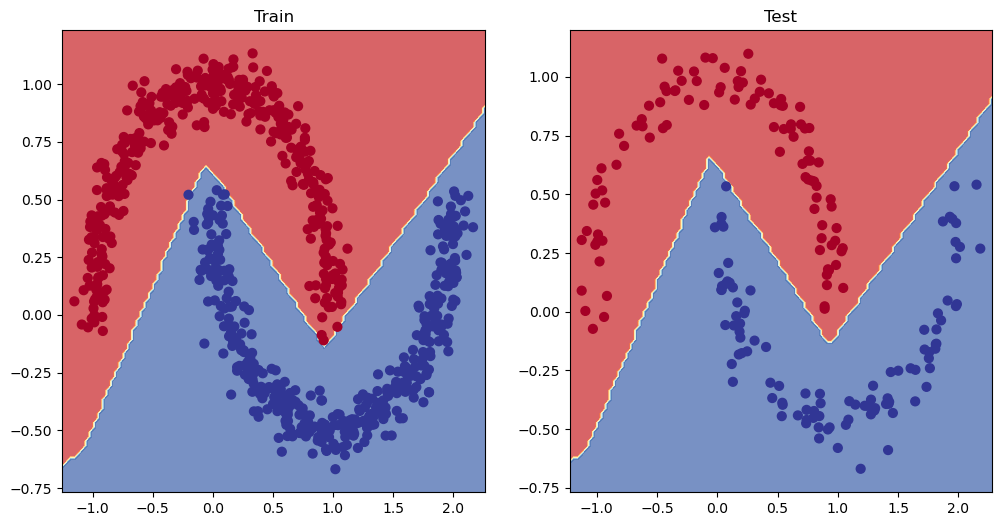

In [68]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_5, X_moons_train, y_moons_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_5, X_moons_test, y_moons_test)


In [69]:
import numpy as np
def tanh(z):
	return (np.exp(z) - np.exp(-z)) / (np.exp(z) + np.exp(-z))

/var/folders/m8/xhbf16sj00b_px7r2lbh9dlr0000gn/T/ipykernel_70090/1366171266.py:1: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  A = torch.range(-100, 100, 1)


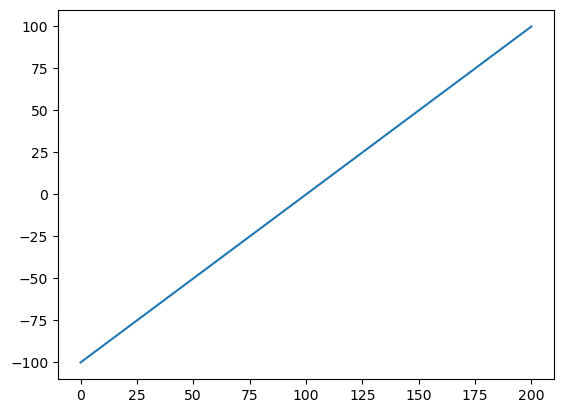

In [70]:
A = torch.range(-100, 100, 1)
plt.plot(A)

/var/folders/m8/xhbf16sj00b_px7r2lbh9dlr0000gn/T/ipykernel_70090/4204696831.py:3: RuntimeWarning: overflow encountered in exp
  return (np.exp(z) - np.exp(-z)) / (np.exp(z) + np.exp(-z))


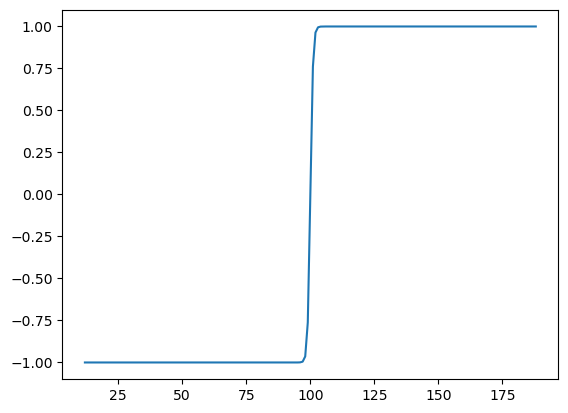

In [71]:
plt.plot(tanh(A))

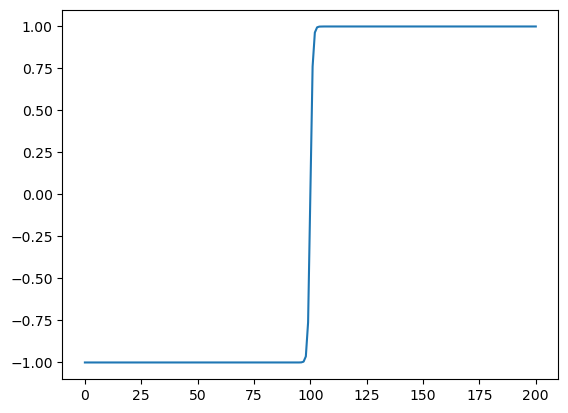

In [72]:
plt.plot(torch.tanh(A))

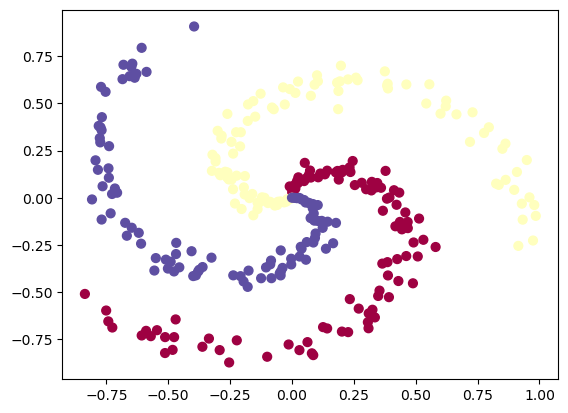

In [164]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [165]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)

X_spiral_train, X_spiral_test, y_spiral_train, y_spiral_test = train_test_split(
                                                                                X, 
                                                                                y,
                                                                                test_size = 0.2,
                                                                                random_state = RANDOM_SEED
)

In [166]:
X_spiral_train.shape, X_spiral_test.shape, y_spiral_train.shape, y_spiral_test.shape

(torch.Size([240, 2]),
 torch.Size([60, 2]),
 torch.Size([240]),
 torch.Size([60]))

In [187]:
class SpiralModelV0(nn.Module):
    def __init__(self, input_feature, output_feature, hidden_units):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_feature, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_feature)
        )
    def forward(self, x):
        return self.linear_layer_stack(x)

model_6 = SpiralModelV0(input_feature=2, output_feature=3, hidden_units=10).to(device)
model_6

SpiralModelV0(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=10, bias=True)
    (5): ReLU()
    (6): Linear(in_features=10, out_features=3, bias=True)
  )
)

In [188]:
X_spiral_train, X_spiral_test = X_spiral_train.to(device), X_spiral_test.to(device)
y_spiral_train, y_spiral_test = y_spiral_train.to(device), y_spiral_test.to(device)

In [189]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_6.parameters(), 
                            lr = 0.02)

In [190]:
X_pred = model_6(X_spiral_train[:5])
X_pred

tensor([[-0.0834, -0.2301, -0.0727],
        [-0.0862, -0.2270, -0.0693],
        [-0.0854, -0.2324, -0.0737],
        [-0.1040, -0.2112, -0.0470],
        [-0.0994, -0.2173, -0.0543]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [191]:
print(torch.softmax(X_pred, dim=1))

tensor([[0.3479, 0.3005, 0.3516],
        [0.3465, 0.3010, 0.3524],
        [0.3478, 0.3003, 0.3519],
        [0.3382, 0.3038, 0.3580],
        [0.3407, 0.3028, 0.3564]], device='mps:0', grad_fn=<SoftmaxBackward0>)


In [192]:
q = torch.argmax(torch.softmax(X_pred[:5], dim=1), dim=1)
q

tensor([2, 2, 2, 2, 2], device='mps:0')

In [193]:
from torchmetrics import Accuracy

accuracy_fn = Accuracy(task = "multiclass", num_classes=3).to(device)
accuracy_fn

Accuracy()

In [194]:
device

device(type='mps')

In [195]:
torch.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)

X_spiral_train, X_spiral_test = X_spiral_train.to(device), X_spiral_test.to(device)
y_spiral_train, y_spiral_test = y_spiral_train.to(device), y_spiral_test.to(device)

epochs = 1000

for epoch in range(epochs):

    # Training 
    model_6.train()

    y_train_logits = model_6(X_spiral_train)
    y_pred_probs = torch.argmax(torch.softmax(y_train_logits, dim=1), dim=1)

    loss = loss_fn(y_train_logits, y_spiral_train)
    train_acc = accuracy_fn(y_pred_probs, y_spiral_train.int())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_6.eval()
    with torch.inference_mode():
        y_test_logits = model_6(X_spiral_test)
        y_pred_probs = torch.argmax(torch.softmax(y_test_logits, dim=1), dim=1)

        test_loss = loss_fn(y_test_logits, y_spiral_test)
        test_acc = accuracy_fn(y_pred_probs, y_spiral_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Training Loss: {loss:.5f}, Training Accuracy: {train_acc:.4f} | Testing Loss: {test_loss:.5f}, Testing Accuracy: {test_acc:.4f}")


Epoch: 0 | Training Loss: 1.10367, Training Accuracy: 0.3250 | Testing Loss: 1.09165, Testing Accuracy: 0.3667
Epoch: 100 | Training Loss: 0.44283, Training Accuracy: 0.7375 | Testing Loss: 0.50136, Testing Accuracy: 0.7333
Epoch: 200 | Training Loss: 0.06010, Training Accuracy: 0.9833 | Testing Loss: 0.06416, Testing Accuracy: 0.9833
Epoch: 300 | Training Loss: 0.02263, Training Accuracy: 0.9917 | Testing Loss: 0.01360, Testing Accuracy: 1.0000
Epoch: 400 | Training Loss: 0.01825, Training Accuracy: 0.9917 | Testing Loss: 0.00567, Testing Accuracy: 1.0000
Epoch: 500 | Training Loss: 0.01644, Training Accuracy: 0.9917 | Testing Loss: 0.00226, Testing Accuracy: 1.0000
Epoch: 600 | Training Loss: 0.01548, Training Accuracy: 0.9917 | Testing Loss: 0.05913, Testing Accuracy: 0.9833
Epoch: 700 | Training Loss: 0.01494, Training Accuracy: 0.9917 | Testing Loss: 0.08153, Testing Accuracy: 0.9833
Epoch: 800 | Training Loss: 0.01478, Training Accuracy: 0.9917 | Testing Loss: 0.12397, Testing Ac

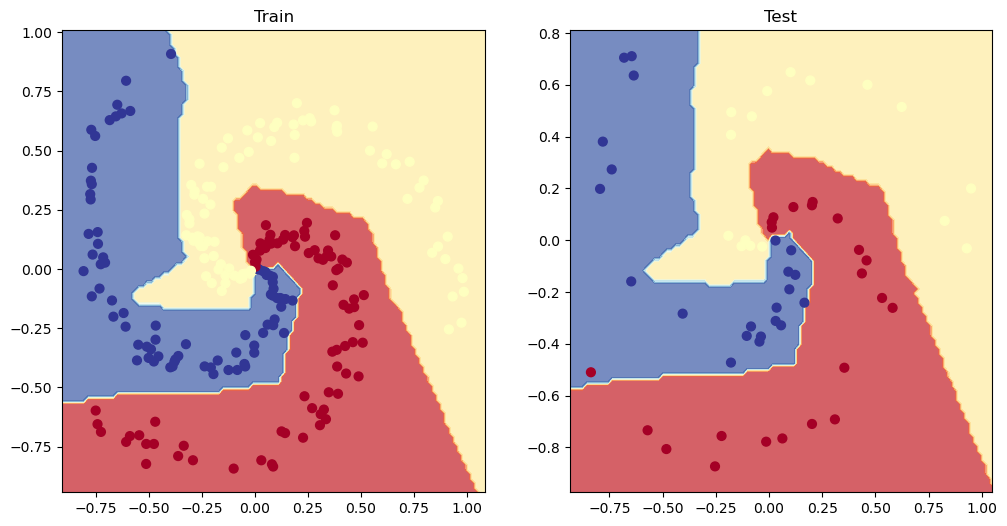

In [196]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_6, X_spiral_train, y_spiral_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_6, X_spiral_test, y_spiral_test)


In [138]:
plot_decision_boundary()

TypeError: plot_decision_boundary() missing 3 required positional arguments: 'model', 'X', and 'y'

In [ ]:
()